# Week 3 Homework

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(2026)

**1. (25 pts) Using the data provided. Generate a line chart such that:**
- **X axis must have:**
   - **A maximum of 10 major tickmarks.**
   - **Each major ticklabels should have the following string format '%.0f'.**
   - **Minor tick marks will be set at 0.5 intervals.**
   - **No minor labels**
- **Y axis must have:**
  - **A major tick mark at each 0.5 interval.**
  - **A custom function formatter that shows two decimals and appends a unit string '{value:.2f} units'.**
  - **An automatic minor locator between major ticks.**

```{note}
Whatever function you use with `FuncFormatter()` make sure that it receives at least two parameters: 
- one for the label you want to format
- one of the position which you can ignore for the purposes of your formatting.
```

**DATA:**

In [13]:
# Data
x = np.linspace(0, 10, 500)
y = np.sin(x) * (1.0 + 0.3 * np.cos(3 * x))

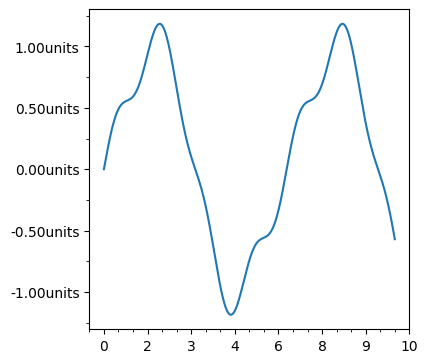

In [20]:
# YOUR CODE HERE
import matplotlib.ticker as ticker
def custom_format(x, pos):
    return f'{x:.2f}units'#used example from class; is 'pos' for the label?

fig = plt.figure(figsize=(4, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
#x axis tick settings
ax.xaxis.set_major_locator(ticker.MaxNLocator(9))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_formatter(ticker.NullFormatter())
#y axis tick settings
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(custom_format))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(n=2))

ax.plot(x,y)
plt.show()

**2. (25 pts) You're comparing pottery assemblages from site HBMH (Horvat Be'er Milka Hasmonean) to regional averages. The pottery is classified into four functional categories: cooking vessels, storage jars, ritual vessels (least common), and other ceramics. Recreate the grouped bar chart shown in the output image.**

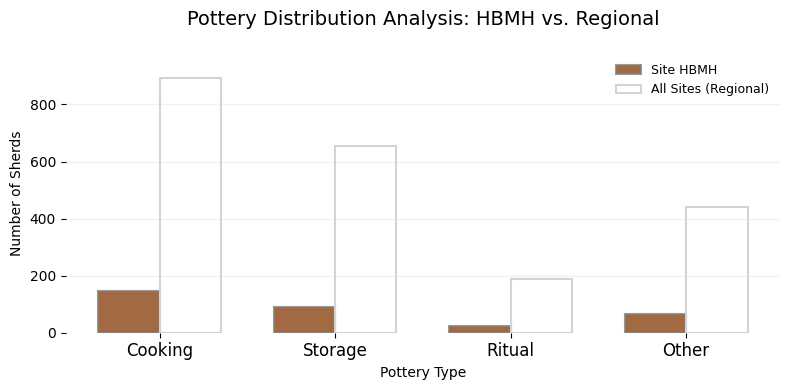

**Requirements:**

- **Figure size: (8, 4)**
- **Grouped bars: bar_width = 0.35**
- **HBMH bars: color='#8B4513', alpha=0.8, edgecolor='gray', linewidth=1.5**
- **Title: 'Pottery Distribution Analysis: HBMH vs. Regional' (fontsize=14)**

*Hint*. To create side-by-side grouped bars, offset the x-positions: use `x_pos - bar_width/2` for HBMH bars and `x_pos + bar_width/2` for All Sites bars.

**DATA:**

In [4]:
# Data
categories = ['Cooking', 'Storage', 'Ritual', 'Other']
hbmh_counts = [145, 89, 23, 67]  
all_sites_counts = [892, 654, 187, 441]  # Regional averages - larger quantities

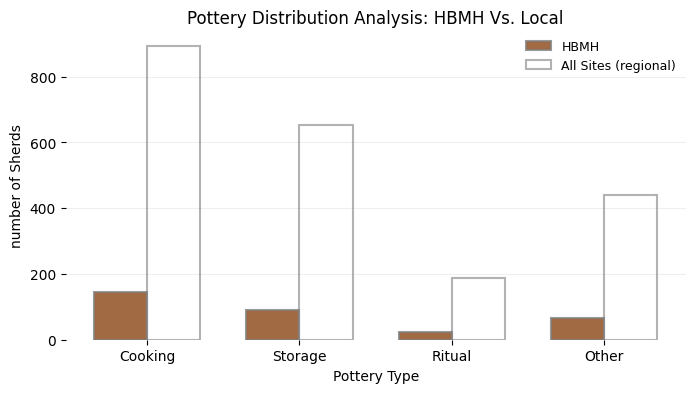

In [60]:
# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt

# Data
group1 = [20, 34, 30, 35]
group2 = [25, 32, 34, 20]

x = np.arange(len(categories))  # label locations
width = 0.35                     # width of the bars

fig, ax = plt.subplots(figsize = (8,4))

ax.bar(x - width/2, hbmh_counts, width, label='HBMH', 
       color='#8B4513', alpha=0.8, edgecolor='gray', linewidth=1.5)
ax.bar(x + width/2, all_sites_counts, width, label='All Sites (regional)', 
       fill = False, edgecolor='gray', linewidth=1.5, alpha = 0.6)

# Labels & formatting
ax.set_ylabel('number of Sherds')
ax.set_title('Pottery Distribution Analysis: HBMH Vs. Local')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_xlabel('Pottery Type')
ax.legend(frameon = False
        , bbox_to_anchor=(0.725,1.01), loc='upper left'
         ,fontsize = 9)

#getting rid of spines
ax.spines['right'].set_visible(False)# right 
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)# right 
ax.spines['left'].set_visible(False)# top

#horizontal grid
ax.yaxis.grid(True, which='major', alpha=0.2)
ax.set_axisbelow(True)  # draw grid lines behind bars


plt.show()


**3. (50 pts) You're creating a visualization showing the vertical distribution of three types of archaeological materials (charcoal, bone fragments, and ceramic sherds) found at different depths in an excavation. The depth axis should appear separately between the charcoal plot and the other two material plots to emphasize the grouping. Recreate the plot shown in the output image.**

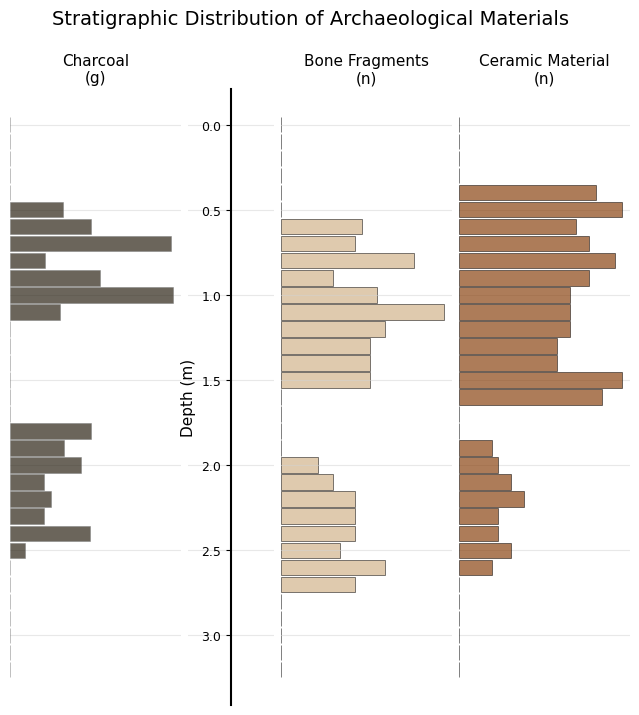

**Requirements:**
- **Figure size: (8, 8)**
- **Four subplots using GridSpec with width_ratios=[1, 0.5, 1, 1], wspace=0.05**
- **Horizontal bar charts (height=0.09)**
- **Colors: Charcoal='#2C2416', Bone='#D2B48C', Ceramic='#8B4513'**
- **All bars: alpha=0.7, edge colors visible**
- **Depth axis inverted (surface at top)**
- **No spines visible on data plots**
- **Y-axis grid on all plots (color='lightgray', alpha=0.5, behind bars)**
- **No x-axis ticks or labels on any plot**
- **Titles with units in parentheses**

*Hint 1 - GridSpec Layout:*
You need 4 subplots where the second one (gs[1]) is dedicated solely to the depth axis with no data plotted. All other plots will share their y-axis with this subplot.

*Hint 2 - Grid Without Visible Ticks:*
To show grid lines without visible tick marks on the data plots, use `ax.tick_params(axis='y', length=0, labelleft=False)` instead of `ax.set_yticks([])`. The latter removes tick positions entirely, which also removes grid lines. Adjust zorder so that the gridlines appear **behind** the bars.

*Hint 3 - Depth Axis Positioning:*
For ax2 (depth axis), position the left spine at the center using `.set_position(('axes', 0.5))` and remove the other three spines. This creates a vertical axis line in the middle of that subplot space, separating the charcoal plot from the bone/ceramic plots.

**DATA:**

In [50]:
# Data
depth = np.arange(0, 3.21, 0.1)  # 0, 0.1, 0.2, ..., 3.2 meters

# Generate CHARCOAL data (grams) - with gaps (some zeros)
charcoal = np.zeros(len(depth))
charcoal_indices_1 = (depth >= 0.5) & (depth <= 1.2)
charcoal_indices_2 = (depth >= 1.8) & (depth <= 2.5)
charcoal[charcoal_indices_1] = np.random.uniform(2, 15, charcoal_indices_1.sum())
charcoal[charcoal_indices_2] = np.random.uniform(1, 8, charcoal_indices_2.sum())

# Generate BONE FRAGMENTS data (counts) - with gaps
bone = np.zeros(len(depth))
bone_indices_1 = (depth >= 0.6) & (depth <= 1.5)
bone_indices_2 = (depth >= 2.0) & (depth <= 2.8)
bone[bone_indices_1] = np.random.poisson(12, bone_indices_1.sum())
bone[bone_indices_2] = np.random.poisson(8, bone_indices_2.sum())

# Generate CERAMIC MATERIAL data (counts) - with gaps
ceramic = np.zeros(len(depth))
ceramic_indices_1 = (depth >= 0.4) & (depth <= 1.6)
ceramic_indices_2 = (depth >= 1.9) & (depth <= 2.6)
ceramic[ceramic_indices_1] = np.random.poisson(20, ceramic_indices_1.sum())
ceramic[ceramic_indices_2] = np.random.poisson(10, ceramic_indices_2.sum())

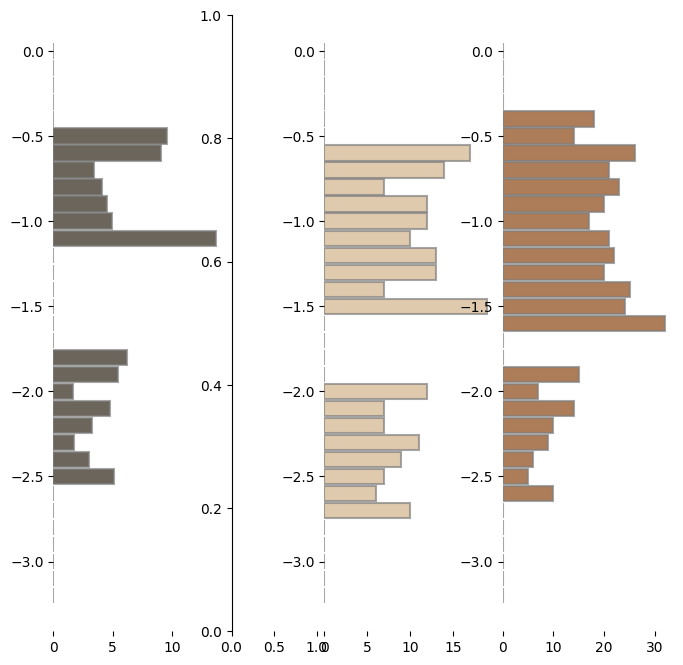

In [62]:
# YOUR CODE HERE
fig = plt.figure(figsize = (8, 8))
gs = fig.add_gridspec(1, 4, width_ratios = [1, 0.5, 1, 1], wspace = 0.05)

# create figures
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])
ax4 = fig.add_subplot(gs[0,3])

axes = [ax1, ax2, ax3, ax4]#for automation

#bar charts
ax1.barh(y = (depth*(-1)),
        width = charcoal,
        height = 0.09,
        label='Charcoal', color='#2C2416',
         edgecolor='grey', linewidth=1.5, alpha=0.7)
ax3.barh(y = (depth*(-1)),
        width = bone,
        height = 0.09,
        label='Bone Fragments', color='#D2B48C',
         edgecolor='grey', linewidth=1.5, alpha=0.7)
ax4.barh(y = (depth*(-1)),
        width = ceramic,
        height = 0.09,
        label='Ceramic Material', color='#8B4513',
         edgecolor='grey', linewidth=1.5, alpha=0.7)

#removing spines
for ax in axes:#using a for loop because this would be very cumbersome
    for spine in ax.spines.values():
        spine.set_visible(False)
        spine.set

# keep left spine only on ax2
ax2.spines['left'].set_visible(True)

#fig.tight_layout()
plt.show()